In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
import yaml
from scipy.spatial.distance import cdist

In [2]:
### Link of the data
root = "ipfs://QmTSoNnvXX9bzu5SgVHeP7hVCuqJKFAkjk21LvzzCSGz9p"

In [3]:
def find_closest_grid_point(target_lon, target_lat, lon_array, lat_array,n_closest=4):
    """
    Find the closest grid point in the dataset to the given lon/lat.
    """
    targets_coords = np.radians([target_lat, target_lon])
    coords = np.column_stack([np.radians(lat_array), np.radians(lon_array)])

    ### calculate haversine distances

    def haversine_distance(coord1, coord2):
        lat1, lon1 = coord1
        lat2, lon2 = coord2
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        radius_earth = 6371  # Earth radius in kilometers
        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        return 2 * np.arcsin(np.sqrt(a)) * radius_earth

    #return targets_coords, coords
    distances = cdist([targets_coords], coords, metric=haversine_distance)[0]
    #closest_indices = np.argsort(distances)[:n_closest]
    closest_indices = np.concat(np.argwhere(distances < 1))  # Only consider points within 1 km
    return closest_indices, distances[closest_indices]

def cal_uv_wind(ds):
    u = -ds.wspd*np.sin(np.deg2rad(ds.wdir))
    v = -ds.wspd*np.cos(np.deg2rad(ds.wdir))
    return u,v

In [4]:
def create_dataset(adcp_u, adcp_v, xband_u, xband_v, uwind, vwind, heading, dist, lon, time):
    """
    Create an xarray Dataset from the matched ADCP and X-band data.
    """
    ds = xr.Dataset(
        {
            'adcp_u': (('time'), adcp_u),
            'adcp_v': (('time'), adcp_v),
            'xband_u': (('time'), xband_u),
            'xband_v': (('time'), xband_v),
            'uwind': (('time'), uwind),
            'vwind': (('time'), vwind),
            'heading': (('time'), heading),
            'dist': (('time'), dist),
            'lon': (('time'), lon),
        },
        coords={
            'time': time
        }
    )
    return ds

In [5]:
def match_adcp_xband_ctd(xband, adcp, ctd_stations, dship, depth=17):
    """
    Match ADCP and X-band data based on CTD stations.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []
    dist_list = []
    lon_list = []
    time_list = []
    uwind_list = []
    vwind_list = []

    for id in ctd_stations.index:
        time_slice = [stations_adcp.iloc[id]['start'], stations_adcp.iloc[id]['end']]
        ds_xband_cut = xband.where((xband.time >= np.datetime64(time_slice[0])) \
                                    & (xband.time <= np.datetime64(time_slice[1])), drop=True)
        times_xband_cut = np.unique(ds_xband_cut.time)
        for times_id in times_xband_cut:
            ds_xband_temp = ds_xband_cut.where(ds_xband_cut.time == times_id, drop=True)
            nearest_adcp = adcp.sel(time=times_id, method='nearest',tolerance='10min')
            nearest_dship = dship.sel(time=times_id, method='nearest',tolerance='10min')
            if ds_xband_temp.time.size > 12 and nearest_adcp.time.size > 0:
                points, dist = find_closest_grid_point(
                    target_lon = nearest_adcp.LONGITUDE.values,
                    target_lat = nearest_adcp.LATITUDE.values,
                    lon_array = ds_xband_temp.longitude.values,
                    lat_array = ds_xband_temp.latitude.values,
                    n_closest=12)
                u_temp,v_temp = cal_uv_wind(nearest_dship)
                adcp_u_list.append(nearest_adcp.sel(DEPTH=depth).U.values)
                adcp_v_list.append(nearest_adcp.sel(DEPTH=depth).V.values)
                heading_list.append(nearest_dship.ship_heading.values)
                xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
                xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
                uwind_list.append(u_temp)
                vwind_list.append(v_temp)
                dist_list.append(dist.mean())
                lon_list.append(nearest_dship.lon.values)
                time_list.append(nearest_dship.time.values)
    return create_dataset(np.array(adcp_u_list), 
                          np.array(adcp_v_list), 
                          np.array(xband_u_list), 
                          np.array(xband_v_list), 
                          np.array(uwind_list),
                          np.array(vwind_list),
                          np.array(heading_list), 
                          np.array(dist_list), 
                          np.array(lon_list), 
                          np.array(time_list))


In [6]:
def match_adcp_xband_movement(xband, adcp, dship, time_slice, depth=17, ship_speed_threshold=4.5):
    """
    Match ADCP and X-band data based on ship movement.
    """
    adcp_u_list = []
    adcp_v_list = []
    xband_u_list = []
    xband_v_list = []
    heading_list = []
    dist_list = []
    lon_list = []
    time_list = []
    uwind_list = []
    vwind_list = []

    ds_dship_stage = dship.sel(time=slice(time_slice[0], time_slice[1]))
    ds_adcp_stage = adcp.sel(time=slice(time_slice[0], time_slice[1]),DEPTH=depth)
    xband_radar_stage = xband.where(
        (xband.time>= np.datetime64(time_slice[0])) & \
         (xband.time<= np.datetime64(time_slice[1])),drop=True)
    
    times_xband_stage = np.unique(xband_radar_stage.time)
    ### find nearest time in adcp and xband
    for times_id in times_xband_stage:
        nearest_adcp = ds_adcp_stage.sel(time=times_id, method='nearest',tolerance='10min')
        nearest_dship = ds_dship_stage.sel(time=times_id, method='nearest',tolerance='10min')
        ds_xband_temp = xband_radar_stage.where(xband_radar_stage.time == times_id, drop=True)

        ### only consider when ship speed is above threshold
        if (nearest_dship.ship_speed.values >= ship_speed_threshold) and \
           (ds_xband_temp.time.size > 96) and (nearest_adcp.time.size > 0):
            points,dist = find_closest_grid_point(
                target_lon = nearest_adcp.LONGITUDE.values,
                target_lat = nearest_adcp.LATITUDE.values,
                lon_array = ds_xband_temp.longitude.values,
                lat_array = ds_xband_temp.latitude.values,
                n_closest=12)
            u_temp,v_temp = cal_uv_wind(nearest_dship)
            adcp_u_list.append(nearest_adcp.U.values)
            adcp_v_list.append(nearest_adcp.V.values)
            xband_u_list.append(ds_xband_temp.isel(measurement=points).eastward_sea_water_velocity.mean().values)
            xband_v_list.append(ds_xband_temp.isel(measurement=points).northward_sea_water_velocity.mean().values)
            uwind_list.append(u_temp)
            vwind_list.append(v_temp)
            heading_list.append(nearest_dship.ship_heading.values)
            dist_list.append(dist.mean())
            lon_list.append(nearest_dship.lon.values)
            time_list.append(nearest_dship.time.values)
    return create_dataset(np.array(adcp_u_list), 
                          np.array(adcp_v_list), 
                          np.array(xband_u_list), 
                          np.array(xband_v_list),
                          np.array(uwind_list),
                          np.array(vwind_list),
                          np.array(heading_list), 
                          np.array(dist_list), 
                          np.array(lon_list), 
                          np.array(time_list))

In [7]:
def calculate_velocity_magnitude(u, v):
    """
    Calculate the velocity magnitude from u and v components.
    """
    return np.sqrt(u**2 + v**2)

def calculate_direction(u, v):
    """
    Calculate the direction of the current from u and v components.
    """
    return (np.rad2deg(np.arctan2(u, v)) + 360) % 360

def calculate_current_mag_dir(u, v):
    """
    Calculate the current magnitude and direction from u and v components.
    """
    magnitude = calculate_velocity_magnitude(u, v)
    direction = calculate_direction(u, v)
    return magnitude, direction

def calculate_current_cross_along(adcp_u, adcp_v, xband_u, xband_v, angle):
    """
    Calculate the current cross-along values.
    """
    # Calculate the cross-along current
    cross_adcp = (adcp_u) * np.cos(np.radians(angle)) - (adcp_v) * np.sin(np.radians(angle))
    cross_xband = (xband_u) * np.cos(np.radians(angle)) - (xband_v) * np.sin(np.radians(angle))
    long_adcp = (adcp_u) * np.sin(np.radians(angle)) + (adcp_v) * np.cos(np.radians(angle))
    long_xband = (xband_u) * np.sin(np.radians(angle)) + (xband_v) * np.cos(np.radians(angle))
    return cross_adcp, cross_xband, long_adcp, long_xband

In [8]:
### Calling radiosondes from METEOR
ds_adcp_75= xr.open_dataset(
    f"{root}/ADCP/met_203_vmadcp_75khz.zarr",engine="zarr").rename({"TIME":"time"})

ds_xband_radar= xr.open_dataset(
    f"{root}/Radar_Derived_Currents_M203.zarr",engine="zarr")

ds_dship= xr.open_dataset(
    f"{root}/DShip.zarr",engine="zarr")


In [9]:
with open("/Users/hans/Documents/bow_tie/actionlog_book/stations_bowtie_ctd.yaml", 'r') as stream:
    dic_ctd = yaml.safe_load(stream)
stations = pd.DataFrame(dic_ctd['stations'])

In [10]:
stations_adcp = stations[stations['start']>=ds_adcp_75.time[0].values].reset_index(drop=True)

In [11]:
ds_ctd_matched = match_adcp_xband_ctd(ds_xband_radar, ds_adcp_75, stations_adcp, ds_dship)
local_offset_ctd = np.floor_divide(ds_ctd_matched.lon.values, 15)
hours_ctd = (ds_ctd_matched.time['time.hour'] + local_offset_ctd) % 24

In [12]:
ds_stage_1 = match_adcp_xband_movement(
    ds_xband_radar, ds_adcp_75, ds_dship, ('2024-08-28', '2024-09-04'), 17, 1
)
local_offset_stage_1 = np.floor_divide(ds_stage_1.lon.values, 15)
hours_stage_1 = (ds_stage_1.time['time.hour'] + local_offset_stage_1) % 24

In [13]:
ds_stage_2 = match_adcp_xband_movement(
    ds_xband_radar, ds_adcp_75, ds_dship, ('2024-09-15', '2024-09-24'), 17, 1)
local_offset_stage_2 = np.floor_divide(ds_stage_2.lon.values, 15)
hours_stage_2 = (ds_stage_2.time['time.hour'] + local_offset_stage_2) % 24

In [14]:
vel_adcp_ctd, dir_adcp_ctd = calculate_current_mag_dir(ds_ctd_matched.adcp_u, ds_ctd_matched.adcp_v)
vel_xband_ctd, dir_xband_ctd = calculate_current_mag_dir(ds_ctd_matched.xband_u, ds_ctd_matched.xband_v)
vel_adcp_stage1, dir_adcp_stage1 = calculate_current_mag_dir(ds_stage_1.adcp_u, ds_stage_1.adcp_v)
vel_xband_stage1, dir_xband_stage1 = calculate_current_mag_dir(ds_stage_1.xband_u, ds_stage_1.xband_v)
vel_wind_stage1, dir_wind_stage1 = calculate_current_mag_dir(ds_stage_1.uwind, ds_stage_1.vwind)
vel_adcp_stage2, dir_adcp_stage2 = calculate_current_mag_dir(ds_stage_2.adcp_u, ds_stage_2.adcp_v)
vel_xband_stage2, dir_xband_stage2 = calculate_current_mag_dir(ds_stage_2.xband_u, ds_stage_2.xband_v)
vel_wind_stage2, dir_wind_stage2 = calculate_current_mag_dir(ds_stage_2.uwind, ds_stage_2.vwind)

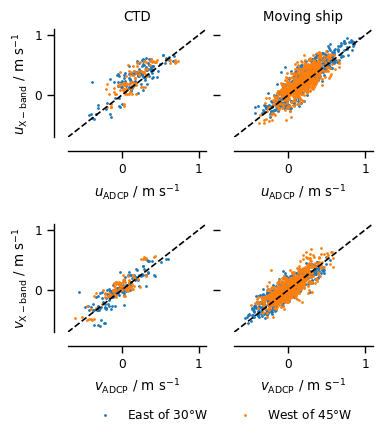

In [15]:
sns.set_context("paper")
fig = plt.figure(figsize=(10/2.54,10/2.54))
ax1 = fig.add_subplot(221)
ax1.plot(ds_ctd_matched.adcp_u.where(ds_ctd_matched.lon>-30), 
         ds_ctd_matched.xband_u.where(ds_ctd_matched.lon>-30), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_ctd_matched.adcp_u.where(ds_ctd_matched.lon<-45), 
         ds_ctd_matched.xband_u.where(ds_ctd_matched.lon<-45), 'o',
         markersize=1, label=r'Western of 45$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')

ax2 = fig.add_subplot(222)
ax2.plot(ds_stage_1.adcp_u.where(ds_stage_1.lon>-30), 
         ds_stage_1.xband_u.where(ds_stage_1.lon>-30), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax2.plot(ds_stage_2.adcp_u.where(ds_stage_2.lon<-45), 
         ds_stage_2.xband_u.where(ds_stage_2.lon<-45), 'o',
         markersize=1, label=r'Western of 45$\degree$W')
ax2.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax2.set_xlim([-0.7,1.1])
ax2.set_ylim([-0.7,1.1])
ax2.set_yticks([0,1])
ax2.set_yticklabels({})
sns.despine(offset=10,ax=ax2)
ax2.spines['left'].set_visible(False)
ax2.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax2.set_title('Moving ship')

ax3 = fig.add_subplot(223)
ax3.plot(ds_ctd_matched.adcp_v.where(ds_ctd_matched.lon>-30), 
         ds_ctd_matched.xband_v.where(ds_ctd_matched.lon>-30), 'o',
         markersize=1, label=r'East of 30$\degree$W')
ax3.plot(ds_ctd_matched.adcp_v.where(ds_ctd_matched.lon<-45), 
         ds_ctd_matched.xband_v.where(ds_ctd_matched.lon<-45), 'o',
         markersize=1, label=r'West of 45$\degree$W')
ax3.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax3.set_xlim([-0.7,1.1])
ax3.set_ylim([-0.7,1.1])
ax3.set_yticks([0,1])
sns.despine(offset=10,ax=ax3)
ax3.set_ylabel(r'$v_{\mathrm{X-band}}$ / m s$^{-1}$')
ax3.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')

ax4 = fig.add_subplot(224)
ax4.plot(ds_stage_1.adcp_v.where(ds_stage_1.lon>-30), 
         ds_stage_1.xband_v.where(ds_stage_1.lon>-30), 'o',
         markersize=1, label=r'East of 30$\degree$W')
ax4.plot(ds_stage_2.adcp_v.where(ds_stage_2.lon<-45), 
         ds_stage_2.xband_v.where(ds_stage_2.lon<-45), 'o',
         markersize=1, label=r'West of 45$\degree$W')
ax4.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax4.set_xlim([-0.7,1.1])
ax4.set_ylim([-0.7,1.1])
ax4.set_yticks([0,1])
ax4.set_yticklabels({})
sns.despine(offset=10,ax=ax4)
ax4.spines['left'].set_visible(False)
ax4.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax4.legend(loc='upper left', bbox_to_anchor=(-1.1,-0.6), ncol=2, frameon=False)

plt.subplots_adjust(hspace=0.8)
plt.savefig('../figures/zonal_meridional_current_adcp_xband.png',
            format='png',dpi=300,bbox_inches='tight',orientation={'landscape'})


Text(0.5, 1.0, 'CTD')

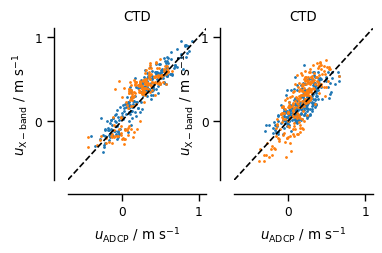

In [16]:
sns.set_context("paper")
fig = plt.figure(figsize=(10/2.54,5/2.54))
ax1 = fig.add_subplot(121)
ax1.plot(ds_stage_1.adcp_u.where((hours_stage_1<=6) | (hours_stage_1>=22)), 
         ds_stage_1.xband_u.where((hours_stage_1<=6) | (hours_stage_1>=22)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_stage_1.adcp_u.where((hours_stage_1>=12) & (hours_stage_1<=19)), 
         ds_stage_1.xband_u.where((hours_stage_1>=12) & (hours_stage_1<=19)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')

ax1 = fig.add_subplot(122)
ax1.plot(ds_stage_2.adcp_u.where((hours_stage_2<=6) | (hours_stage_2>=22)), 
         ds_stage_2.xband_u.where((hours_stage_2<=6) | (hours_stage_2>=22)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot(ds_stage_2.adcp_u.where((hours_stage_2>=12) & (hours_stage_2<=19)), 
         ds_stage_2.xband_u.where((hours_stage_2>=12) & (hours_stage_2<=19)), 'o',
         markersize=1, label=r'Eastern of 30$\degree$W')
ax1.plot([-0.7,1.1],[-0.7,1.1],'--k')
ax1.set_xlim([-0.7,1.1])
ax1.set_ylim([-0.7,1.1])
ax1.set_yticks([0,1])
sns.despine(offset=10,ax=ax1)
ax1.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
ax1.set_title('CTD')


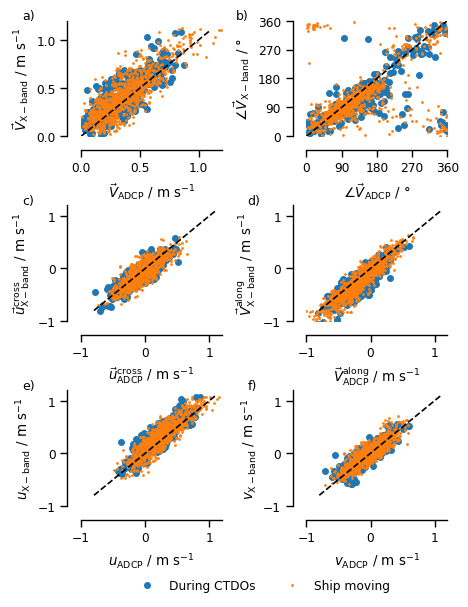

In [295]:
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(321)
ax1.plot(vel_adcp_ctd,vel_xband_ctd,'o',markersize=4,label='During CTDs')
ax1.plot(vel_adcp_stage1,vel_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax1.plot([0,1.1],[0,1.1],'k--')
ax1.set_xlim(0,1.2)
ax1.set_ylim(0,1.2)
ax1.set_yticks([0,0.5,1])
ax1.set_xticks([0,0.5,1])
ax1.set_ylabel(r'$\vec{V}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax1.set_xlabel(r'$\vec{V}_{\mathrm{ADCP}}$ / m s$^{-1}$')
sns.despine(offset=10,ax=ax1)
plt.text(-0.42, 1.1, 'a)', transform=ax1.transAxes, fontsize=9, va='top', ha='left')

ax2 = fig.add_subplot(322)
ax2.plot(dir_adcp_ctd,dir_xband_ctd,'o',markersize=4,label='During CTDs')
ax2.plot(dir_adcp_stage1,dir_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax2.plot([0,360],[0,360],'k--')
ax2.set_xlim(0,360)
ax2.set_ylim(0,360)
ax2.set_yticks([0,90,180,270,360])
ax2.set_xticks([0,90,180,270,360])
sns.despine(offset=10,ax=ax2)
ax2.set_ylabel(r'$\angle \vec{V}_{\mathrm{X-band}}$ / $\degree$')
ax2.set_xlabel(r'$\angle  \vec{V}_{\mathrm{ADCP}}$ / $\degree$')
plt.text(-0.5, 1.1, 'b)', transform=ax2.transAxes, fontsize=9, va='top', ha='left')

ax3 = fig.add_subplot(323)
ax3.plot(cross_adcp_ctd,cross_xband_ctd,'o',markersize=4,label='During CTDs')
ax3.plot(cross_adcp_stage1,cross_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax3.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax3.set_xlim(-1,1.2)
ax3.set_ylim(-1,1.2)
ax3.set_yticks([-1,0,1])
ax3.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax3)
ax3.set_ylabel(r'$\vec{u}^\mathrm{cross}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax3.set_xlabel(r'$\vec{u}^\mathrm{cross}_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'c)', transform=ax3.transAxes, fontsize=9, va='top', ha='left')

ax4 = fig.add_subplot(324)
ax4.plot(long_adcp_ctd,long_xband_ctd,'o',markersize=4,label='During CTDs')
ax4.plot(long_adcp_stage1,long_xband_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax4.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax4.set_xlim(-1,1.2)
ax4.set_ylim(-1,1.2)
ax4.set_yticks([-1,0,1])
ax4.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax4)
ax4.set_ylabel(r'$\vec{V}^\mathrm{along}_{\mathrm{X-band}}$ / m s$^{-1}$')
ax4.set_xlabel(r'$\vec{V}^\mathrm{along}_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'd)', transform=ax4.transAxes, fontsize=9, va='top', ha='left')

ax5 = fig.add_subplot(325)
ax5.plot(adcp_u_ctd,xband_u_ctd,'o',markersize=4,label='During CTDs')
ax5.plot(adcp_u_stage1,xband_u_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax5.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax5.set_xlim(-1,1.2)
ax5.set_ylim(-1,1.2)
ax5.set_yticks([-1,0,1])
ax5.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax5)
ax5.set_ylabel(r'$u_{\mathrm{X-band}}$ / m s$^{-1}$')
ax5.set_xlabel(r'$u_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'e)', transform=ax5.transAxes, fontsize=9, va='top', ha='left')

ax6 = fig.add_subplot(326)
ax6.plot(adcp_v_ctd,xband_v_ctd,'o',markersize=4,label='During CTDOs')
ax6.plot(adcp_v_stage1,xband_v_stage1,'o',color='tab:orange',markersize=1,label = 'Ship moving')
ax6.plot([-0.8,1.1],[-0.8,1.1],'k--')
ax6.set_xlim(-1,1.2)
ax6.set_ylim(-1,1.2)
ax6.set_yticks([-1,0,1])
ax6.set_xticks([-1,0,1])
sns.despine(offset=10,ax=ax6)
ax6.set_ylabel(r'$v_{\mathrm{X-band}}$ / m s$^{-1}$')
ax6.set_xlabel(r'$v_{\mathrm{ADCP}}$ / m s$^{-1}$')
plt.text(-0.42, 1.1, 'f)', transform=ax6.transAxes, fontsize=9, va='top', ha='left')

plt.subplots_adjust(wspace=0.6, hspace=0.6)
ax6.legend(loc='upper left',ncol=2, bbox_to_anchor=(-1.3,-0.54),frameon=False)
plt.savefig('../figures/analyses_adcp_x_band.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})